## ejercicio
**Objetivo:**  
Implementar y evaluar un modelo de clasificación utilizando un dataset de clasificación de scikit‑learn. 

**Paso a paso:**

- Carga y exploración de datos  
- Normalización de características  
- Entrenamiento de un modelo de clasificación  
- Evaluación del rendimiento (matriz de confusión, accuracy, curva ROC y AUC)  
- Interpretación resultados



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
np.random.seed(42)

- Cargar el dataset de cáncer de mama de scikit‑learn.  
- Convertir los datos en un DataFrame de pandas.  
- Explorar el dataset: dimensiones, primeras filas y distribución de la variable objetivo.

**Tareas:**  
1. Utiliza la función `load_breast_cancer()` para cargar los datos.  
2. Crea un DataFrame con las características y agrega la columna 'target'.  
3. Muestra el tamaño del dataset, las primeras filas y la distribución de las clases.


In [1]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Mostrar dimensiones y primeras filas
print("Dimensiones del dataset:", df.shape)

# Distribución de la variable objetivo
print("Primeras 5 filas del dataset:")
print(df.head())

Dimensiones del dataset: (569, 31)
Primeras 5 filas del dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  

In [2]:
# Distribución de la variable objetivo ('target')
# identificar si las clases están balanceadas o desbalanceadas.
print("Distribución de la variable 'target':")
print(df['target'].value_counts())

Distribución de la variable 'target':
target
1    357
0    212
Name: count, dtype: int64


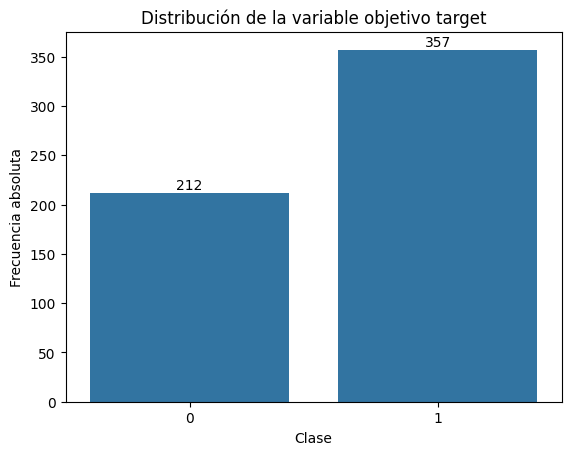

In [3]:
# Visualización de la distribución de la variable objetivo
ax = sns.countplot(x='target', data=df)
plt.title("Distribución de la variable objetivo target")
plt.xlabel("Clase")
plt.ylabel("Frecuencia absoluta")

# Agregar el número de cada barra encima de ella
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura)}', 
                (p.get_x() + p.get_width() / 2, altura), 
                ha='center', 
                va='bottom')

plt.show()


In [4]:
# 1. Definir las variables predictoras (X) y la variable respuesta (y)
X = df.drop('target', axis=1)
y = df['target']
#2 Dividir el dataset en conjuntos de entrenamiento y prueba (70%-30%) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
#3 Ajusta el escalador con el conjunto de entrenamiento y transforma ambos conjuntos.

# Inicializar el escalador
scaler = StandardScaler()
# Ajustar el escalador usando el conjunto de entrenamiento y transformar este conjunto
X_train_scaled = scaler.fit_transform(X_train)
# Transformar el conjunto de prueba (usando el mismo escalador)
X_test_scaled = scaler.transform(X_test)

# Imprimir las dimensiones para verificar
print("Dimensiones del conjunto de entrenamiento:", X_train_scaled.shape)
print("Dimensiones del conjunto de prueba:", X_test_scaled.shape)

Dimensiones del conjunto de entrenamiento: (398, 30)
Dimensiones del conjunto de prueba: (171, 30)
